# spaCy upgrade and package installation.

In [ ]:
!pip install -U spacy==3.*
!python -m spacy download en_core_web_sm
!python -m spacy info

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 93.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.

============================== Info about spaCy ==============================

spaCy version    3.8.11                        
Location         /usr/local/lib/python3.12/dist-packages/spacy
Platform         Linux-6.6.113+-x86_64-with-glibc2.35
Python version   3.12.12                       
Pipelines        en_core_web_sm (3.8.0)        



In [ ]:
# Upgrade gensim in case.
# !pip install --upgrade numpy
!pip install -U gensim==4.*

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 52.1 MB/s eta 0:00:00


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import random
import spacy
import numpy as np

from gensim import models, corpora
from gensim import similarities
from gensim.models.coherencemodel import CoherenceModel
from wordcloud import WordCloud

# First pass at building an LDA topic model for our corpus

We'll use a corpus of over 90,000 CNN news articles originally compiled for training question answering models. I lightly processed them to remove some metadata and put them on Google Drive.
([original source](https://cs.nyu.edu/~kcho/DMQA/))
<br><br>
To retrieve the corpus from Google Drive, we'll use the **gdown** library which I've already installed:<br>
https://github.com/wkentaro/gdown

In [ ]:
import locale
def getpreferredencoding(do_setlocale = True):
    return "UTF-8"

locale.getpreferredencoding = getpreferredencoding

In [ ]:
!pip install --upgrade --no-cache-dir gdown

In [ ]:
# Download the CNN corpus.
!gdown 'https://drive.google.com/uc?id=122fC9XpNwFKx0ryRVKJz5MWUTzA3Vpsf'

Downloading...
From (original): https://drive.google.com/uc?id=122fC9XpNwFKx0ryRVKJz5MWUTzA3Vpsf
From (redirected): https://drive.google.com/uc?id=122fC9XpNwFKx0ryRVKJz5MWUTzA3Vpsf&confirm=t&uuid=dfb754d9-5bd5-409f-b82e-013fcbbc993f
To: /content/cnn_articles.txt
100% 365M/365M [00:03<00:00, 95.2MB/s]


The corpus is one large text file with each article in the corpus separated by an *@delimiter* string. We'll split the articles and place them in a list.

In [ ]:
with open('cnn_articles.txt', 'r', encoding='utf8') as f:
  articles = f.read().split('@delimiter')

In [ ]:
DATASET_SIZE = 54000
dataset = articles[:DATASET_SIZE]

In [ ]:
NUM_PROCESS = 4

In [ ]:
spacy.require_gpu()

In [ ]:
NUM_TOPICS = 20

# Before preprocessing

In [ ]:
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

def basic_filter(tokenized_doc):
  return [t.lemma_ for t in tokenized_doc if
          t.is_alpha and \
          not t.is_punct and \
          not t.is_space]

In [ ]:
%%time
tokenized_articles = list(map(basic_filter, nlp.pipe(dataset, batch_size = 512)))
tokenized_articles = [doc for doc in tokenized_articles if len(doc) != 0]

CPU times: user 20min 26s, sys: 2.27 s, total: 20min 29s
Wall time: 20min 35s


In [ ]:
N = len(tokenized_articles)
print("Number of documents (N):", N)

# Total tokens
total_tokens = sum(len(doc) for doc in tokenized_articles)
print("Total tokens:", total_tokens)

# Vocabulary
vocab = corpora.Dictionary(tokenized_articles)
V = len(vocab)
print("Vocabulary size (|V|):", V)

# After preprocessing

In [ ]:
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

def improved_filter(tokenized_doc):
  return [t.lemma_ for t in tokenized_doc if
          t.is_alpha and \
          not t.is_punct and \
          not t.is_space and \
          not t.is_stop and \
          t.pos_ in ['NOUN', 'VERB', 'ADJ']]

In [ ]:
%%time
pre_tokenized_articles = list(map(improved_filter, nlp.pipe(dataset, batch_size = 512)))
pre_tokenized_articles = [doc for doc in pre_tokenized_articles if len(doc) != 0]

CPU times: user 19min 49s, sys: 783 ms, total: 19min 50s
Wall time: 19min 56s


In [ ]:
pre_N = len(pre_tokenized_articles)
print("Number of documents (N):", pre_N)

# Total tokens
pre_total_tokens = sum(len(doc) for doc in pre_tokenized_articles)
print("Total tokens:", pre_total_tokens)

# Vocabulary
pre_vocab = corpora.Dictionary(pre_tokenized_articles)
pre_V = len(pre_vocab)
print("Vocabulary size (|V|):", pre_V)

# Vocabulary after filtering extreme word
pre_vocab.filter_extremes(no_below=5, no_above=0.5)
pre_V_filtered = len(pre_vocab)
print("Vocabulary size after filtering extreme word (|V|):", pre_V_filtered)

In [ ]:
# Rebuild bag of words.
corpus_bow = [pre_vocab.doc2bow(article) for article in pre_tokenized_articles]

In [ ]:
%%time
lda_model = models.ldamodel.LdaModel(corpus=corpus_bow,
                                     id2word=pre_vocab,
                                     num_topics=NUM_TOPICS,
                                     passes=10,
                                     alpha='auto',
                                     eta='auto',
                                     random_state=1)

CPU times: user 7min 5s, sys: 468 ms, total: 7min 5s
Wall time: 7min 8s


In [ ]:
lda_model.print_topics()

[(0,
  '0.023*"government" + 0.018*"country" + 0.012*"protest" + 0.010*"political" + 0.010*"right" + 0.010*"leader" + 0.008*"protester" + 0.008*"group" + 0.006*"power" + 0.006*"violence"'),
 (1,
  '0.038*"police" + 0.015*"officer" + 0.012*"man" + 0.012*"gun" + 0.012*"report" + 0.011*"kill" + 0.011*"find" + 0.011*"shoot" + 0.010*"authority" + 0.010*"accord"'),
 (2,
  '0.025*"flight" + 0.022*"plane" + 0.018*"passenger" + 0.015*"airport" + 0.015*"ship" + 0.014*"crash" + 0.013*"fly" + 0.011*"pilot" + 0.011*"crew" + 0.010*"airline"'),
 (3,
  '0.018*"health" + 0.014*"doctor" + 0.012*"patient" + 0.011*"drug" + 0.010*"medical" + 0.010*"hospital" + 0.010*"disease" + 0.009*"care" + 0.009*"cancer" + 0.007*"treatment"'),
 (4,
  '0.013*"film" + 0.010*"movie" + 0.009*"star" + 0.009*"music" + 0.008*"play" + 0.007*"good" + 0.007*"book" + 0.006*"story" + 0.006*"write" + 0.006*"fan"'),
 (5,
  '0.030*"minute" + 0.026*"goal" + 0.020*"second" + 0.020*"point" + 0.018*"score" + 0.018*"win" + 0.015*"match" + 

We set the training algorithm to learn priors for *alpha* and *eta*.

In [ ]:
print(lda_model.alpha)
print(lda_model.eta)

[0.09683681 0.09711323 0.07417341 0.07301625 0.1165451  0.05248353
 0.09000999 0.06678237 0.06449885 0.14353895 0.14824656 0.07741432
 0.10634557 0.10946827 0.07063509 0.23408373 0.06899365 0.07957923
 0.08242349 0.05631234]
[0.09703767 0.05310193 0.04710509 ... 0.03840727 0.03840727 0.03840727]


The *alpha* and *eta* values the training algorithm arrived at are well below 1. This translates to most articles being dominated by one or just a few topics, and most topics being dominated by a handful of words.

In [ ]:
article_idx = 0
print(dataset[article_idx][:300])

 -- Children in war-ravaged Afghanistan are safer than those growing up in London or New York, NATO's top civilian envoy says.

Mark Sedwill, the senior civilian representative for NATO, made the comments on an episode of CBBC's "Newsround," which is airing Monday.

In the show -- a BBC current-affa


In [ ]:
# Return topic distribution for an article sorted by probability.
topics = sorted(lda_model.get_document_topics(corpus_bow_w_pos_filtered[article_idx]), key=lambda tup: tup[1])[::-1]
topics

[(19, np.float32(0.3030118)),
 (15, np.float32(0.1802794)),
 (7, np.float32(0.15507449)),
 (3, np.float32(0.12361046)),
 (10, np.float32(0.09227073)),
 (9, np.float32(0.08035613)),
 (14, np.float32(0.031250447)),
 (4, np.float32(0.027284784))]

In [ ]:
# View the words of the top topic from the previous article.
lda_model.show_topic(topics[0][0])

[('military', np.float32(0.036581714)),
 ('force', np.float32(0.025392361)),
 ('war', np.float32(0.019167943)),
 ('troop', np.float32(0.016066775)),
 ('soldier', np.float32(0.01541371)),
 ('kill', np.float32(0.013525697)),
 ('civilian', np.float32(0.012419805)),
 ('government', np.float32(0.011923265)),
 ('syrian', np.float32(0.011846411)),
 ('group', np.float32(0.011352649))]

In [ ]:
# View the words of the second-most prevalent topic from the previous article.
lda_model.show_topic(topics[1][0])

[('family', np.float32(0.0177515)),
 ('know', np.float32(0.015820753)),
 ('child', np.float32(0.015412351)),
 ('go', np.float32(0.014562136)),
 ('life', np.float32(0.013196082)),
 ('want', np.float32(0.011776178)),
 ('think', np.float32(0.011553195)),
 ('day', np.float32(0.0111651905)),
 ('get', np.float32(0.0088439975)),
 ('old', np.float32(0.008357632))]

In [ ]:
def get_top_topics(article_idx, min_topic_prob):

  # Sort from highest to lowest topic probability.
  topic_prob_pairs = sorted(lda_model.get_document_topics(corpus_bow_w_pos_filtered[article_idx],
                                                          minimum_probability=min_topic_prob),
                            key=lambda tup: tup[1])[::-1]

  word_prob_pairs = [lda_model.show_topic(pair[0]) for pair in topic_prob_pairs]
  topic_words = [[pair[0] for pair in collection] for collection in word_prob_pairs]

  data = {
      'Major Topics': topic_prob_pairs,
      'Topic Words': topic_words
  }

  return pd.DataFrame(data)


In [ ]:
pd.set_option('max_colwidth', 600)
snippet_length = 300
min_topic_prob = 0.25

article_idx = 1
print(dataset[article_idx][:snippet_length])
get_top_topics(article_idx, min_topic_prob)


 -- The Hard Rock Cafe franchise, famed for its rock'n'roll memorabilia, is expanding its reach into hotels and casinos -- but its chief executive says the brand will remain "special."

"We don't want to be in every street corner, in every city of the UK," Hard Rock's Hamish Dodds told CNN.

"We wa


,Major Topics,Topic Words
0,"(13, 0.39445996)","[city, hotel, food, good, place, room, day, local, art, include]"
1,"(12, 0.34422863)","[money, pay, government, country, business, company, cost, economic, job, work]"


In [ ]:
article_idx = 10
print(dataset[article_idx][:snippet_length])
get_top_topics(article_idx, min_topic_prob)


 -- The House Republican leadership upped the ante Thursday in the ongoing debate over the size and scope of the federal budget, unveiling a proposal to cut spending by $375 billion over the next five years.

House GOP Minority Whip Eric Cantor has been an outspoken critic of Democratic budget prop


,Major Topics,Topic Words
0,"(12, 0.66983074)","[money, pay, government, country, business, company, cost, economic, job, work]"


In [ ]:
article_idx = 100
print(dataset[article_idx][:snippet_length])
get_top_topics(article_idx, min_topic_prob)


 -- A tip led to Wednesday's arrest in Louisiana of a suspected serial bank robber dubbed the "Granddad Bandit," federal authorities said.

Michael Francis Mara, 52, was captured at his home in Baton Rouge, FBI Special Agent Sheila Thorne told CNN.

The FBI went to the residence to execute an arres


,Major Topics,Topic Words
0,"(14, 0.4840694)","[police, kill, officer, man, authority, report, shoot, attack, accord, suspect]"


In [ ]:
article_idx = 100
print(dataset[article_idx][:snippet_length])
get_top_topics(article_idx, min_topic_prob)


 -- A tip led to Wednesday's arrest in Louisiana of a suspected serial bank robber dubbed the "Granddad Bandit," federal authorities said.

Michael Francis Mara, 52, was captured at his home in Baton Rouge, FBI Special Agent Sheila Thorne told CNN.

The FBI went to the residence to execute an arres


,Major Topics,Topic Words
0,"(1, 0.51882166)","[police, officer, man, gun, report, kill, find, shoot, authority, accord]"


In [ ]:
article_idx = 100
print(dataset[article_idx][:snippet_length])
get_top_topics(article_idx, 0.25)


 -- A tip led to Wednesday's arrest in Louisiana of a suspected serial bank robber dubbed the "Granddad Bandit," federal authorities said.

Michael Francis Mara, 52, was captured at his home in Baton Rouge, FBI Special Agent Sheila Thorne told CNN.

The FBI went to the residence to execute an arres


,Major Topics,Topic Words
0,"(1, 0.51884633)","[police, officer, man, gun, report, kill, find, shoot, authority, accord]"


# Evaluation and Visualization

In [ ]:
%%time
coherence_model_lda = CoherenceModel(model=lda_model, texts=tokenized_articles_w_pos, dictionary=dictionary_w_pos, coherence='u_mass')
coherence_lda = coherence_model_lda.get_coherence()
print('\nCoherence Score: ', coherence_lda)


Coherence Score:  -1.5753450819549872
CPU times: user 12.6 s, sys: 367 ms, total: 12.9 s
Wall time: 13 s


## Human evaluation
Because the quantitative metrics aren't entirely correlated with quality, human judgment still plays a large role in topic model evaluation.


We can get someone to look at the topic words to see how interpretable they are.

There are also subjective tests like **word intrusion** and **topic intrusion**.
<br><br>
**Word intrusion** is taking words which belong to a topic, injecting a word from another topic into the collection, and seeing whether a human can easily identify the intruder word. The more easily the intruder word is spotted, the more well-formed the topic. For example, which word doesn't belong in this topic?<br>
*{apple, lemon, tomato, horse, grape}*

We can also visualize them with word clouds.

In [ ]:
def render_word_cloud(model, rows, cols, max_words):
  word_cloud = WordCloud(background_color='white', max_words=max_words, prefer_horizontal=1.0)
  fig, axes = plt.subplots(rows, cols, figsize=(15,15))

  for i, ax in enumerate(axes.flatten()):
      fig.add_subplot(ax)
      topic_words = dict(model.show_topic(i))
      word_cloud.generate_from_frequencies(topic_words)
      plt.gca().imshow(word_cloud, interpolation='bilinear')
      plt.gca().set_title('Topic {id}'.format(id=i))
      plt.gca().axis('off')

  plt.axis('off')
  plt.show()

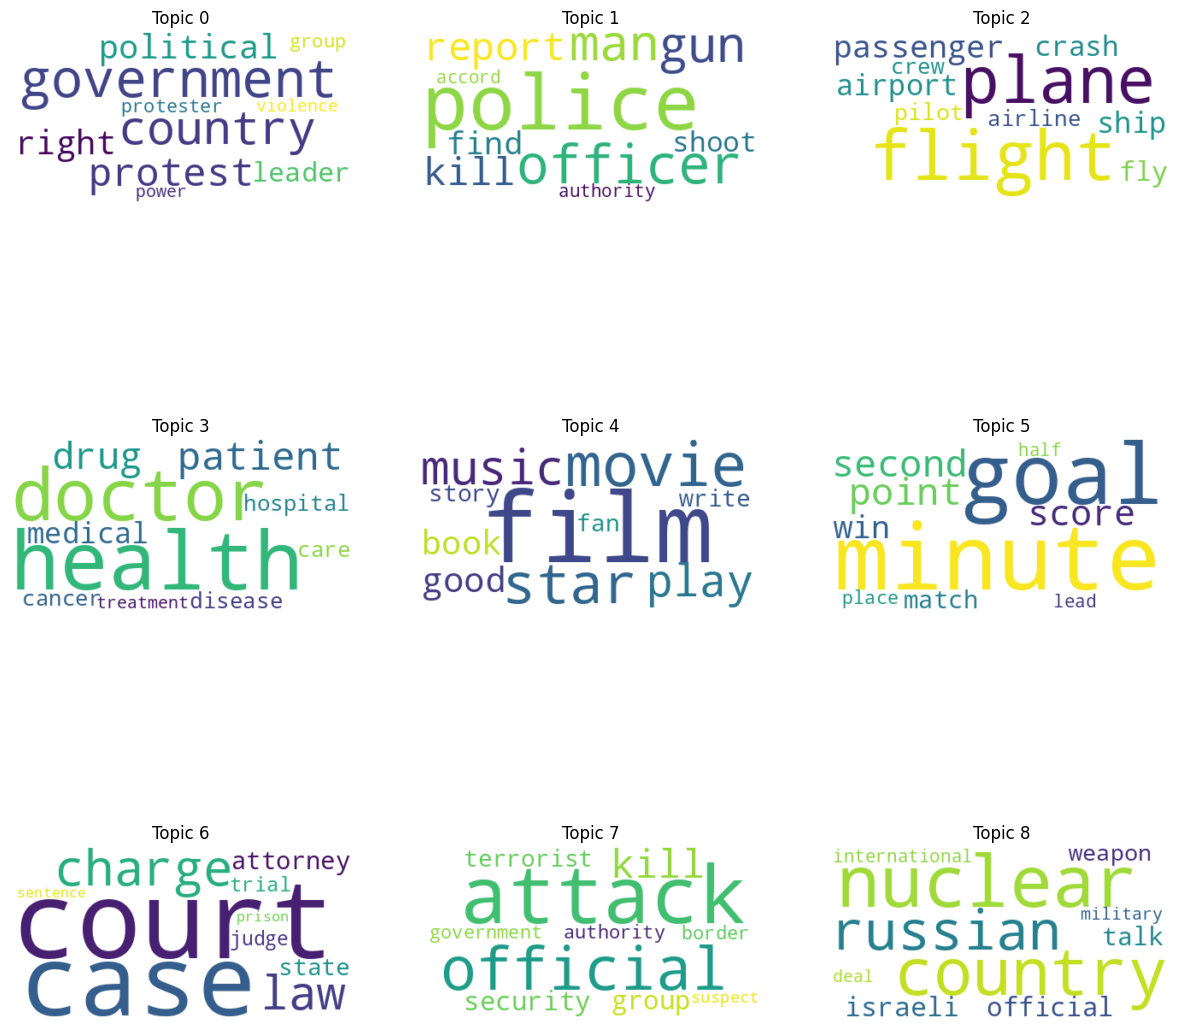

In [ ]:
# Here we'll visualize the first nine topics.
render_word_cloud(lda_model, 3, 3, 10)

# Finding similar documents.

In [ ]:
lda_index = similarities.MatrixSimilarity(lda_model[corpus_bow_w_pos_filtered], num_features=len(dictionary_w_pos))

In [ ]:
def get_similar_articles(index, model, article_bow, top_n=5, first_m_words=300):
  # model[article_bow] retrieves the topic distribution for the BOW.
  # index[model[article_bow] compares the topic distribution for the BOW against the similarity index previously computed.
  similar_docs = index[model[article_bow]]
  top_n_docs = sorted(enumerate(similar_docs), key=lambda item: -item[1])[1:top_n+1]

  # Return a list of tuples with each tuple: (article id, similarity score, first_m_words of article)
  return list(map(lambda entry: (entry[0], entry[1], articles[entry[0]][:first_m_words]), top_n_docs))

In [ ]:
article_idx = 0
print(dataset[article_idx][:snippet_length], '\n')
get_similar_articles(lda_index, lda_model, corpus_bow_w_pos_filtered[article_idx])

 -- Children in war-ravaged Afghanistan are safer than those growing up in London or New York, NATO's top civilian envoy says.

Mark Sedwill, the senior civilian representative for NATO, made the comments on an episode of CBBC's "Newsround," which is airing Monday.

In the show -- a BBC current-affa 



[(27636,
  np.float32(0.9355745),
  '\nThe parents of Kayla Mueller are imploring ISIS to contact them. They believe -- or at least hope -- that their daughter may still be alive.\n\n"We have sent you a private message and ask that you respond to us privately," Carl and Marsha Mueller said in a statement.\n\nThe couple is not giving intervi'),
 (26103,
  np.float32(0.9228256),
  "\nBritish aid worker David Haines has been executed by ISIS militants, according to a video posted Saturday to a website associated with the group, making him the third Western captive to be killed by the Islamist extremist group in recent weeks.\n\nThe ISIS video post showing Haines' beheading called "),
 (10990,
  np.float32(0.9226513),
  "\nOne child died and several others were hurt in a grenade attack on a children's Sunday-school class in Kenya, the Kenya Red Cross said.\n\nA Kenyan hospital reported seven children wounded.\n\nThe Kenya Red Cross and local media described the incident at St. Polycarp chu

In [ ]:
article_idx = 10
print(dataset[article_idx][:snippet_length], '\n')
get_similar_articles(lda_index, lda_model, corpus_bow_w_pos_filtered[article_idx])


 -- The House Republican leadership upped the ante Thursday in the ongoing debate over the size and scope of the federal budget, unveiling a proposal to cut spending by $375 billion over the next five years.

House GOP Minority Whip Eric Cantor has been an outspoken critic of Democratic budget prop 



[(34748,
  np.float32(0.99804753),
  '\nIn a 2011 conversation about the Affordable Care Act, MIT economist Jonathan Gruber, one of the architects of the law more commonly known as Obamacare, talked about how the bill would get rid of all tax credits for employer-based health insurance through "mislabeling" what the tax is and who it wou'),
 (3547,
  np.float32(0.99779963),
  '\n -- The House of Representatives voted Wednesday to give the Treasury Department the power to ban future "unreasonable and excessive" compensation at companies receiving federal bailout money.\n\nThe bill would give Treasury Secretary Tim Geithner greater say on executive compensation.\n\nThe Pay for P'),
 (2804,
  np.float32(0.99758327),
  '\n -- Congressional Republicans tore into the Obama administration over the economic stimulus plan Wednesday, arguing that the White House is mishandling the distribution of the money while overstating the ability of the package to create jobs.\n\nPresident Obama says his a

In [ ]:
article_idx = 100
print(dataset[article_idx][:snippet_length], '\n')
get_similar_articles(lda_index, lda_model, corpus_bow_w_pos_filtered[article_idx])


 -- A tip led to Wednesday's arrest in Louisiana of a suspected serial bank robber dubbed the "Granddad Bandit," federal authorities said.

Michael Francis Mara, 52, was captured at his home in Baton Rouge, FBI Special Agent Sheila Thorne told CNN.

The FBI went to the residence to execute an arres 



[(70,
  np.float32(0.9378367),
  "\n -- Haiti's poverty has been much discussed since its massive earthquake, but little has been said of its rich, and equally fraught, history.\n\nFor African-Americans, Haiti's tragedy hits close to home. For more than two centuries the tiny, at times fragile, republic has inspired black political act"),
 (113,
  np.float32(0.9378367),
  "\nEaster is unique on the Christian calendar, a major point in the cycle of the religious year, and one that has always been able to resist the commercialization and culture warring that surrounds Christmas. That's in part because Easter is genuinely about how religious impulses, and patterns, can op"),
 (243,
  np.float32(0.9378367),
  "\nObamacare might be off to a slow start but it's starting to pick up steam, at least in states that are not using the beleaguered HealthCare.gov website.\n\nBlocked out at www.HealthCare.gov? Bypass on way soon, feds say\n\nFor the past month, CNN has conducted a state-by-state surv

In [ ]:
test_article = "Capricorn Business Acquisitions Inc. (TSXV: CAK.H) (the “Company“) is pleased to announce that its board has approved the issuance of 70,000 stock options (“Stock Options“) to directors on April 19, 2020."

article_tokens = list(map(improved_filter, [nlp(test_article)]))[0]
article_bow = dictionary_w_pos.doc2bow(article_tokens)
get_similar_articles(lda_index, lda_model, article_bow)

[(49256,
  np.float32(0.9953381),
  "\n -- The federal agency that protects the nation's borders is doing a shoddy job protecting the nation's wallet, abusing an overtime fund to the tune of $8.7 million annually, according to a government watchdog.\n\nThe U.S. Office of Special Counsel, an independent federal agency that receives whistle"),
 (19020,
  np.float32(0.99207276),
  "\n -- About 83,000 Defense Department employees and contractors with security clearances to protect the nation's secrets have delinquent federal tax debts totaling $730 million, according to an internal government audit.\n\nThe findings in the new Government Accountability Office study raise security c"),
 (5749,
  np.float32(0.9919059),
  '\n -- The U.S. Defense Department cannot account for about $2 billion it was given to cover Iraq-related expenses and is not providing Iraq with a complete list of U.S.-funded reconstruction projects, according to two new government audits.\n\nThe reports come from the offic

In [ ]:
test_article = "DEA agent sentenced to 12 years in prison for conspiring with Colombian drug cartel."

article_tokens = list(map(improved_filter, [nlp(test_article)]))[0]
article_bow = dictionary_w_pos.doc2bow(article_tokens)
get_similar_articles(lda_index, lda_model, article_bow)

[(18372,
  np.float32(0.99328494),
  '\n -- A Canadian citizen was sentenced Thursday in Chicago to 14 years in prison for aiding a plot to attack a Danish newspaper that published cartoons depicting the Prophet Mohammed.\n\nTahawwur Rana, 52, was convicted in June 2011 of conspiracy to provide material support in the plot against the Morg'),
 (7524,
  np.float32(0.99172115),
  "\n -- A federal grand jury indicted four more people on charges involving the 2008 terrorist attacks in Mumbai, India, that left more than 160 people dead.\n\nThe case is linked to David Headley, who pleaded guilty last year to all 12 charges against him in connection with the four-day siege on India's"),
 (46191,
  np.float32(0.9912313),
  '\n -- A Jordanian court Thursday acquitted radical cleric Abu Qatada of charges of conspiracy to bomb an American school in the late 1990s, state media reported.\n\nQatada, whose real name is Omar Othman, was also charged with a 2000 attempt to bomb millennium celebrations 